In [1]:
import jax.random as jrandom
import jax.tree_util as jtu
import jax.numpy as jnp

from diffrax import diffeqsolve, ControlTerm, Euler, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree, Tsit5, VirtualSTLATree, STLAControlTerm, STLAMultiTerm, SEA, ShARK, PIDController

import diffrax
import math
import matplotlib.pyplot as plt

def plot_sol(sol):
    plt.plot(sol.ts, sol.ys[:,0], label="x")
    plt.plot(sol.ts, sol.ys[:,1], label="v")
    plt.legend()
    plt.show()

In [2]:
def drift(t, y, args):
    gamma, u, grad_f = args
    x, v = y[0], y[1]
    d_x = v
    d_v = -gamma * v - u * grad_f(x)
    d_y = jnp.array([d_x, d_v], dtype=jnp.float32)
    return d_y

def diffusion(t, y, args):
    gamma, u, _ = args
    d_v = jnp.sqrt(2*gamma*u)
    d_y = jnp.array([0, d_v], dtype=jnp.float32)
    return d_y

t0, t1 = 1, 20
brownian_motion = VirtualSTLATree(t0, t1, tol=2**-8, shape=(), key=jrandom.PRNGKey(2))
termsEuler = MultiTerm(ODETerm(drift), ControlTerm(diffusion, brownian_motion))
terms = STLAMultiTerm(ODETerm(drift), STLAControlTerm(diffusion, brownian_motion))
saveat = SaveAt(ts=jnp.linspace(t0, t1, 1000))
args = (10.0, 3.0, lambda x: x)

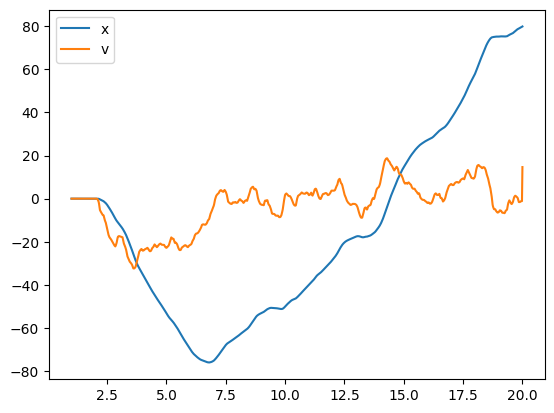

In [3]:
solSRK = diffeqsolve(terms, ShARK(), t0, t1, dt0=0.05, y0=jnp.array([0, 0], dtype=jnp.float32), args=args, saveat=saveat)
plot_sol(solSRK)

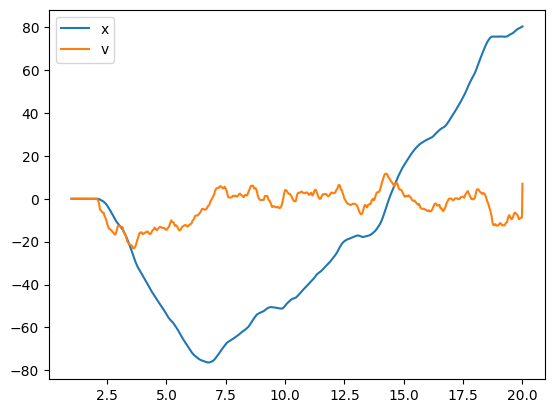

In [4]:
solSE = diffeqsolve(terms, SEA(), t0, t1, dt0=0.05, y0=jnp.array([0, 0], dtype=jnp.float32), args=args, saveat=saveat)
plot_sol(solSE)

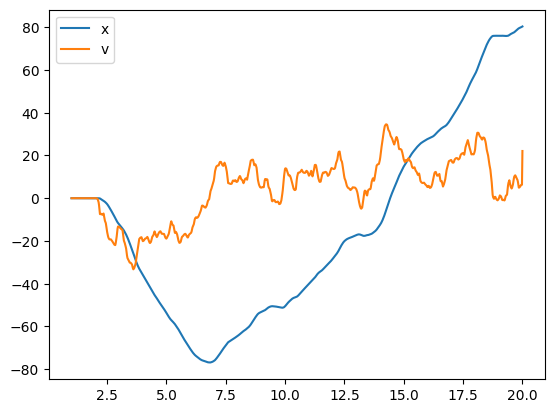

In [5]:
solEuler = diffeqsolve(termsEuler, Euler(), t0, t1, dt0=0.05, y0=jnp.array([0, 0], dtype=jnp.float32), args=args,
                    saveat=saveat)
plot_sol(solEuler)

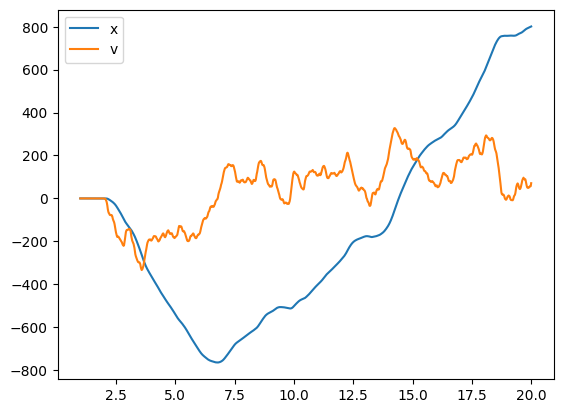

In [6]:
solPrecise = diffeqsolve(termsEuler, Euler(), t0, t1, dt0=0.005, y0=jnp.array([0, 0], dtype=jnp.float32), args=args,
                    saveat=saveat)
plot_sol(solPrecise)

In [7]:
print(f"Euler:    {solEuler.ys[-1]}")
print(f"SE:       {solSE.ys[-1]}")
print(f"SRK:      {solSRK.ys[-1]}")
print(f"Precise:  {solPrecise.ys[-1]}")

Euler:    [80.3329  22.08495]
SE:       [80.31212   6.999156]
SRK:      [79.850365 14.643974]
Precise:  [801.0653    71.042786]


In [3]:
stepsize_controller = PIDController(rtol=1e-5, atol=1e-5)
solSRK_PID = diffeqsolve(terms, ShARK(), t0, t1, dt0=0.1, y0=jnp.array([0, 0], dtype=jnp.float32), args=args, saveat=saveat, stepsize_controller=stepsize_controller)
plot_sol(solSRK_PID)

RuntimeError: Cannot use adaptive step sizes with a solver that does not provide error estimates.